In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# (step 1): masks have been applied in 
# apply_ice_and_land_mask_to_JRA_outputs.ipynb
# apply_ice_and_land_mask_to_ERA_outputs.ipynb

# (step 2): yearly means have been computed in
# compute_yearly_mean_lat_weighted_JRA_outputs.ipynb
# compute_yearly_mean_lat_weighted_JRAraw_outputs.ipynb
# compute_yearly_mean_lat_weighted_ERA_outputs.ipynb


In [3]:
PATH_era = "/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_ERA5.TL319_t232.daily_SST_ERA5_all/YEARLY/"
PATH_jra = "/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA.TL319_t232.daily_SST_ERA5/YEARLY/"
PATH_jra_raw = "/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA55raw.TL319_t232.daily_SST_ERA5/YEARLY/"

ocn_filename_era = "1959_2019_ocn_yearly_weighted_means_" 
ocn_filename_jra = "1959_2019_ocn_yearly_weighted_means_"
ocn_filename_jra_raw = "1959_2019_ocn_yearly_weighted_means_"

atm_filename_era = "1959_2019_atm_yearly_weighted_means_" 
atm_filename_jra = "1959_2019_atm_yearly_weighted_means_"
atm_filename_jra_raw = "1959_2019_atm_yearly_weighted_means_"

In [4]:
ocn_era_mask = xr.open_dataset(PATH_era + ocn_filename_era + "with_ice_mask.nc")
ocn_era_no_mask = xr.open_dataset(PATH_era + ocn_filename_era + "no_ice_mask.nc")

ocn_jra_mask = xr.open_dataset(PATH_jra + ocn_filename_jra + "with_ice_mask.nc")
ocn_jra_no_mask = xr.open_dataset(PATH_jra + ocn_filename_jra + "no_ice_mask.nc")

ocn_jra_raw_mask = xr.open_dataset(PATH_jra_raw + ocn_filename_jra_raw + "with_ice_mask.nc")
ocn_jra_raw_no_mask = xr.open_dataset(PATH_jra_raw + ocn_filename_jra_raw + "no_ice_mask.nc")


atm_era_mask = xr.open_dataset(PATH_era + atm_filename_era + "with_ice_mask.nc")
atm_era_no_mask = xr.open_dataset(PATH_era + atm_filename_era + "no_ice_mask.nc")

atm_jra_mask = xr.open_dataset(PATH_jra + atm_filename_jra + "with_ice_mask.nc")
atm_jra_no_mask = xr.open_dataset(PATH_jra + atm_filename_jra + "no_ice_mask.nc")

atm_jra_raw_mask = xr.open_dataset(PATH_jra_raw + atm_filename_jra_raw + "with_ice_mask.nc")
atm_jra_raw_no_mask = xr.open_dataset(PATH_jra_raw + atm_filename_jra_raw + "no_ice_mask.nc")

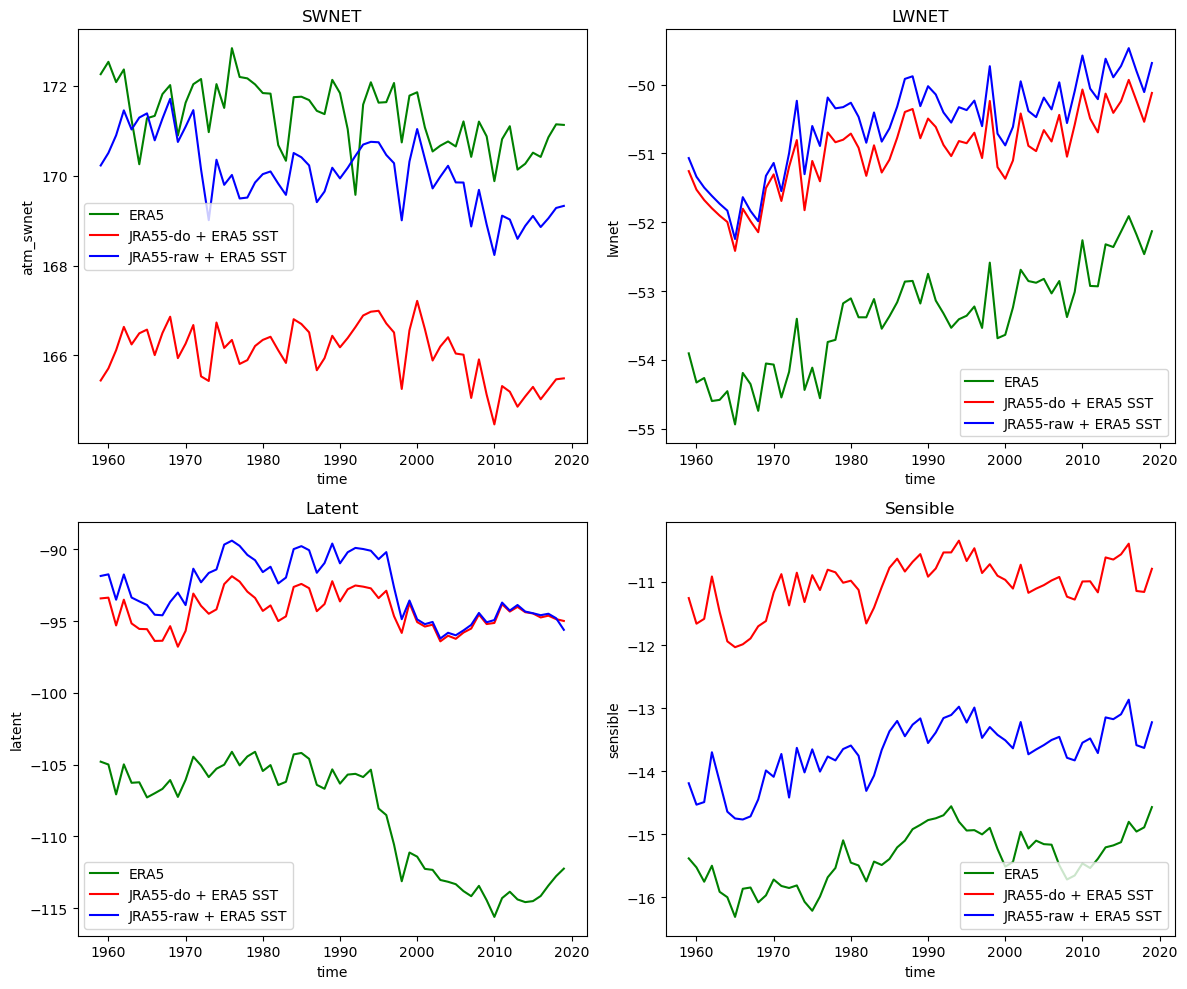

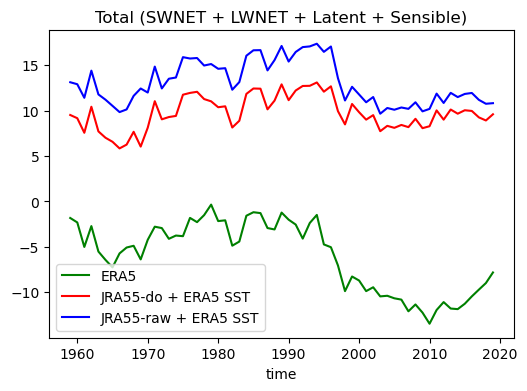

In [5]:
# List of variables to plot
variables = ["atm_swnet", "lwnet", "latent", "sensible"]
titles = ["SWNET", "LWNET", "Latent", "Sensible"]

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # 2x2 grid for 4 variables

# Loop through variables and plot
for ax, var, title in zip(axes.flat, variables, titles):
    if var == 'atm_swnet':   
        atm_era_mask[var].plot(ax=ax, label="ERA5", color = 'green')
        # atm_era_no_mask[var].plot(ax=ax, label="ERA5 (no ice mask)", color = 'green', linestyle = 'dashed')
        atm_jra_mask[var].plot(ax=ax, label="JRA55-do + ERA5 SST", color = 'red')
        # atm_jra_no_mask[var].plot(ax=ax, label="JRA55-do + ERA5 SST (no ice mask)", color = 'red', linestyle = 'dashed')
        atm_jra_raw_mask[var].plot(ax=ax, label="JRA55-raw + ERA5 SST", color = 'blue')
        # atm_jra_raw_no_mask[var].plot(ax=ax, label="JRA55-raw + ERA5 SST (no ice mask)", color = 'blue', linestyle = 'dashed')

    else:
        ocn_era_mask[var].plot(ax=ax, label="ERA5", color = 'green')
        # ocn_era_no_mask[var].plot(ax=ax, label="ERA5 (no ice mask)", color = 'green', linestyle = 'dashed')
        ocn_jra_mask[var].plot(ax=ax, label="JRA55-do + ERA5 SST", color = 'red')
        # ocn_jra_no_mask[var].plot(ax=ax, label="JRA55-do + ERA5 SST (no ice mask)", color = 'red', linestyle = 'dashed')
        ocn_jra_raw_mask[var].plot(ax=ax, label="JRA55-raw + ERA5 SST", color = 'blue')
        # ocn_jra_raw_no_mask[var].plot(ax=ax, label="JRA55-raw + ERA5 SST (no ice mask)", color = 'blue', linestyle = 'dashed')

    ax.set_title(f"{title}")
    ax.legend()

plt.tight_layout()
plt.show()

# Compute and plot the sum of all components
sum_era = ocn_era_mask['latent'] + ocn_era_mask['sensible'] + ocn_era_mask['lwnet'] + atm_era_mask['atm_swnet']
sum_jra = ocn_jra_mask['latent'] + ocn_jra_mask['sensible'] + ocn_jra_mask['lwnet'] + atm_jra_mask['atm_swnet']
sum_jra_raw = ocn_jra_raw_mask['latent'] + ocn_jra_raw_mask['sensible'] + ocn_jra_raw_mask['lwnet'] + atm_jra_raw_mask['atm_swnet']


plt.figure(figsize=(6, 4))
sum_era.plot(label="ERA5", color = 'green')
sum_jra.plot(label="JRA55-do + ERA5 SST",  color = 'red')
sum_jra_raw.plot(label="JRA55-raw + ERA5 SST",  color = 'blue')


plt.title("Total (SWNET + LWNET + Latent + Sensible)")
plt.legend()
plt.show()
